<a href="https://colab.research.google.com/github/ayushmant908-web/machine_learning-100-Days/blob/main/Ridge_regression_regularization_ml_day53_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression,SGDRegressor
from sklearn.preprocessing import PolynomialFeatures,StandardScaler
from sklearn.pipeline import Pipeline

In [ ]:
X=6*np.random.rand(200,1)-3
y=0.8*X**2+0.9*X+2+np.random.randn(200,1)

# y = 0.8x^2 + 0.9x + 2

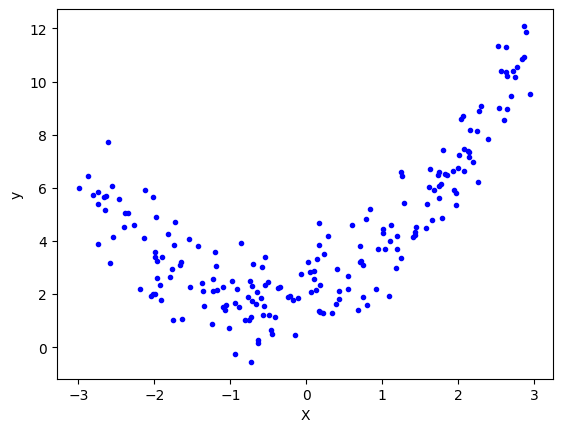

In [ ]:
plt.plot(X,y,'b. ')
plt.xlabel('X')
plt.ylabel('y')
plt.show()

In [ ]:
#train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=2)

In [ ]:
# Applying linear regression
lr=LinearRegression()

In [ ]:
lr.fit(X_train,y_train)

LinearRegression()

In [ ]:
y_pred=lr.predict(X_test)

In [ ]:
r2_score(y_test,y_pred)

0.325626885177307

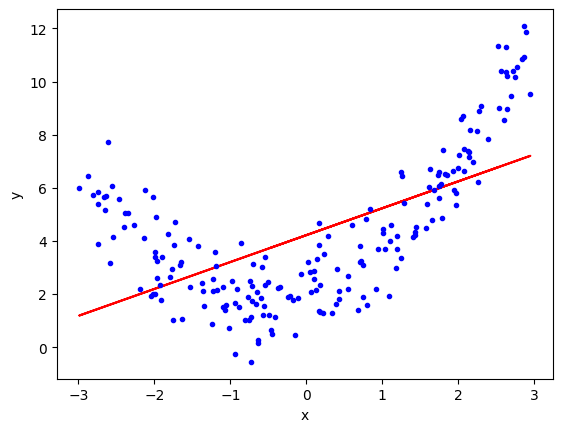

In [ ]:
plt.plot(X_train,lr.predict(X_train),color='red')
plt.plot(X,y,'b. ')
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [ ]:
# Applying Polynomial Linear Regression
# degree 2
poly=PolynomialFeatures(degree=2,include_bias=True)
X_train_transform=poly.fit_transform(X_train)
X_test_transform=poly.transform(X_test)

In [ ]:
print(X_train[0])
print(X_train_transform[0])

[-0.46237388]
[ 1.         -0.46237388  0.21378961]


<h1><b>include_bias Parameter</b></h1>

In [ ]:
lr=LinearRegression()

In [ ]:
lr.fit(X_train_transform,y_train)

LinearRegression()

In [ ]:
y_pred=lr.predict(X_test_transform)

In [ ]:
r2_score(y_test,y_pred)

0.8383694224875772

In [ ]:
print(lr.coef_)
print(lr.intercept_)

[[0.         0.87209977 0.79633279]]
[2.02847879]


In [ ]:
X_new=np.linspace(-3,3,200).reshape(200,1)
X_new_poly=poly.transform(X_new)
y_new=lr.predict(X_new_poly)


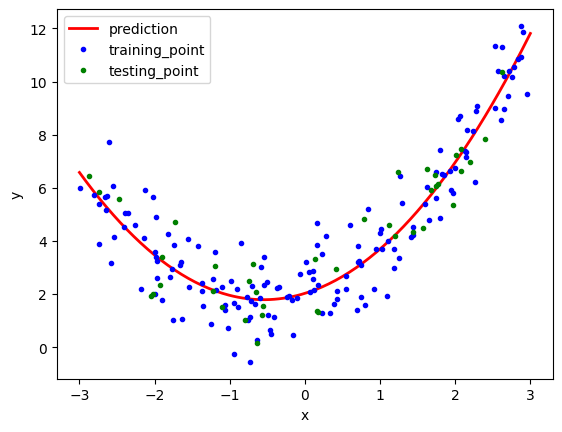

In [ ]:
plt.plot(X_new,y_new,'r-',linewidth=2,label='prediction')
plt.plot(X_train,y_train,'b. ',label='training_point')
plt.plot(X_test,y_test,'g. ',label='testing_point')
plt.legend()
plt.xlabel('x')
plt.ylabel('y')
plt.show()

In [ ]:
def Polynomial_regression(degree):
  X_new= np.linspace(-3,3,100).reshape(100,1)
  X_new_poly=poly.transform(X_new)
  polybig_feature=PolynomialFeatures(degree=degree,include_bias=False)

  std_scalere=StandardScaler()
  lin_reg=LinearRegression()
  polynomial_regression=Pipeline([

                                  ('polnomial_features',polybig_feature),
                                  ('std_scaler',std_scalere),
                                  ('lin_reg',lin_reg),

  ])
  polynomial_regression.fit(X,y)
  y_newbig=polynomial_regression.predict(X_new)
  plt.plot(X_new,y_newbig,'r',label='Degree'+str(degree),linewidth=2)

  plt.plot(X_train,y_train,'b. ',linewidth=3)
  plt.plot(X_test,y_test,'g. ',linewidth=3)
  plt.legend(loc='upper left')
  plt.axis([-3,3,0,10])
  plt.xlabel('x')
  plt.ylabel('y')
  plt.show()


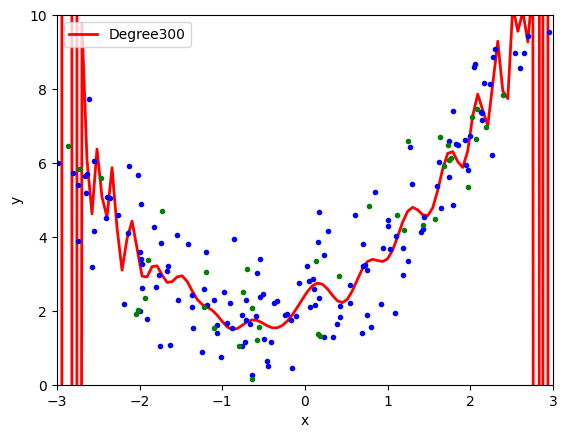

In [ ]:
Polynomial_regression(300)

In [ ]:
poly.powers_

array([[0],
       [1],
       [2]])

/usr/local/lib/python3.13/dist-packages/sklearn/utils/validation.py:1408: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


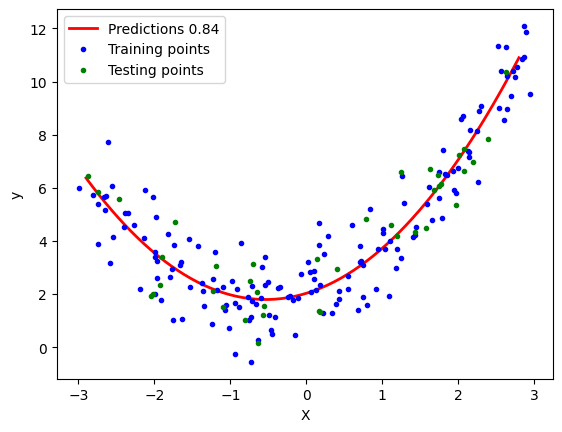

In [ ]:
# Applying Gradient Descent

poly = PolynomialFeatures(degree=2)

X_train_trans = poly.fit_transform(X_train)
X_test_trans = poly.transform(X_test)

sgd = SGDRegressor(max_iter=100)
sgd.fit(X_train_trans,y_train)

X_new=np.linspace(-2.9, 2.8, 200).reshape(200, 1)
X_new_poly = poly.transform(X_new)
y_new = sgd.predict(X_new_poly)

y_pred = sgd.predict(X_test_trans)

plt.plot(X_new, y_new, "r-", linewidth=2, label="Predictions " + str(round(r2_score(y_test,y_pred),2)))
plt.plot(X_train, y_train, "b.",label='Training points')
plt.plot(X_test, y_test, "g.",label='Testing points')
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()

In [ ]:
# 3D polynomial regression
x = 7 * np.random.rand(100, 1) - 2.8
y = 7 * np.random.rand(100, 1) - 2.8

z = x**2 + y**2 + 0.2*x + 0.2*y + 0.1*x*y +2 + np.random.randn(100, 1)
# z = x^2 + y^2 + 0.2x + 0.2y + 0.1xy + 2

In [ ]:
import plotly.express as px
df = px.data.iris()
fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())
fig.show()

In [ ]:

lr = LinearRegression()
lr.fit(np.array([x,y]).reshape(100,2),z)

x_input = np.linspace(x.min(), x.max(), 10)
y_input = np.linspace(y.min(), y.max(), 10)
xGrid, yGrid = np.meshgrid(x_input,y_input)

final = np.vstack((xGrid.ravel().reshape(1,100),yGrid.ravel().reshape(1,100))).T

z_final = lr.predict(final).reshape(10,10)

In [ ]:
import plotly.graph_objects as go

fig = px.scatter_3d(df, x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final ))

fig.show()

In [ ]:

X_multi = np.array([x,y]).reshape(100,2)
X_multi.shape

(100, 2)

In [ ]:
poly = PolynomialFeatures(degree=40)
X_multi_trans = poly.fit_transform(X_multi)

In [ ]:


print("Input", poly.n_features_in_)
print("Output", poly.n_output_features_)
print("Powers\n", poly.powers_)

Input 2
Output 861
Powers
 [[ 0  0]
 [ 1  0]
 [ 0  1]
 ...
 [ 2 38]
 [ 1 39]
 [ 0 40]]


In [ ]:
X_multi_trans.shape

(100, 861)

In [ ]:

lr = LinearRegression()
lr.fit(X_multi_trans,z)

LinearRegression()

In [ ]:
X_test_multi = poly.transform(final)

In [ ]:

z_final = lr.predict(X_multi_trans).reshape(10,10)

In [ ]:
fig = px.scatter_3d(x=x.ravel(), y=y.ravel(), z=z.ravel())

fig.add_trace(go.Surface(x = x_input, y = y_input, z =z_final))

fig.update_layout(scene = dict(zaxis = dict(range=[0,35])))

fig.show()